Feature values (X):
[[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]
 [0.31198904]
 [0.11616722]
 [1.73235229]
 [1.20223002]
 [1.41614516]]

Target values (y):
[6.33428778 9.40527849 8.48372443 5.60438199 4.71643995 5.29307969
 5.82639572 8.67878666 6.79819647 7.74667842]

Mean Absolute Error Manual: 0.5913425779189777
Mean Absolute Error Built-in: 0.5913425779189777

Mean Squared Error Manual: 0.6536995137170021
Mean Squared Error Built-in: 0.6536995137170021

Root Mean Squared Error Manual: 0.8085168605026132
Root Mean Squared Error Built-in: 0.8085168605026132

R-squared (R2) Score Manual: 0.8072059636181392
R-squared (R2) Score Built-in: 0.8072059636181392

Confusion Matrix:
 [[70  1]
 [ 4 39]]


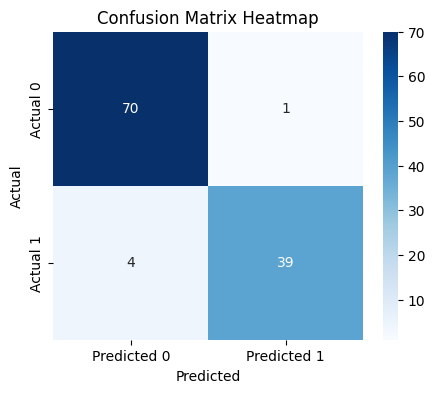


Accuracy Manual: 0.956140350877193
Accuracy Built-in: 0.956140350877193

Precision Manual: 0.975
Precision Built-in: 0.975

Recall Manual: 0.9069767441860465
Recall Built-in: 0.9069767441860465

F1 Score Manual: 0.9397590361445783
F1 Score Built-in: 0.9397590361445783

ROC-AUC Score: 0.9977071732721914


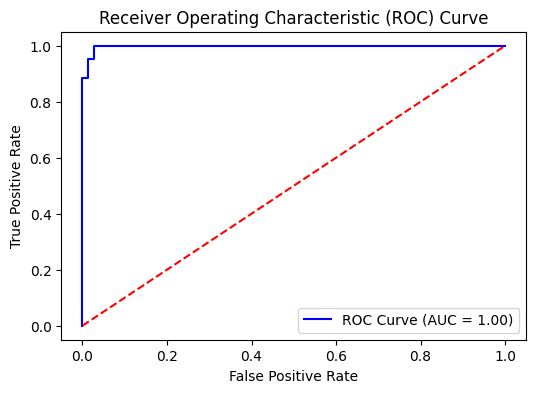


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    roc_curve
)



np.random.seed(42)

X = 2 * np.random.rand(100, 1)

y = 4 + 3 * X.flatten() + np.random.randn(100)

print("Feature values (X):")
print(X[:10])

print("\nTarget values (y):")
print(y[:10])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

def manual_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def manual_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def manual_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def manual_r2(y_true, y_pred):

    ss_res = np.sum((y_true - y_pred) ** 2)

    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

mae_manual = manual_mae(y_test, y_pred)
mse_manual = manual_mse(y_test, y_pred)
rmse_manual = manual_rmse(y_test, y_pred)
r2_manual = manual_r2(y_test, y_pred)

mae_builtin = mean_absolute_error(y_test, y_pred)

mse_builtin = mean_squared_error(y_test, y_pred)

rmse_builtin = np.sqrt(mean_squared_error(y_test, y_pred))

r2_builtin = r2_score(y_test, y_pred)

print("\nMean Absolute Error Manual:", mae_manual)
print("Mean Absolute Error Built-in:", mae_builtin)

print("\nMean Squared Error Manual:", mse_manual)
print("Mean Squared Error Built-in:", mse_builtin)

print("\nRoot Mean Squared Error Manual:", rmse_manual)
print("Root Mean Squared Error Built-in:", rmse_builtin)

print("\nR-squared (R2) Score Manual:", r2_manual)
print("R-squared (R2) Score Built-in:", r2_builtin)

# Classification

df = pd.read_csv("/content/cancer.csv")

encoder = LabelEncoder()

df['diagnosis'] = encoder.fit_transform(df['diagnosis'])

X = df.drop(columns=['diagnosis'])

if 'id' in X.columns:
    X = X.drop(columns=['id'])

# Drop the 'Unnamed: 32' column if it exists and contains all NaNs
if 'Unnamed: 32' in X.columns and X['Unnamed: 32'].isnull().all():
    X = X.drop(columns=['Unnamed: 32'])

# Handle missing values in X before splitting
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

def manual_confusion_matrix(y_true, y_pred):

    TP = 0
    TN = 0
    FP = 0
    FN = 0

    for actual, predicted in zip(y_true, y_pred):

        if actual == 1 and predicted == 1:
            TP += 1

        elif actual == 0 and predicted == 0:
            TN += 1

        elif actual == 0 and predicted == 1:
            FP += 1

        elif actual == 1 and predicted == 0:
            FN += 1

    return TP, TN, FP, FN

TP, TN, FP, FN = manual_confusion_matrix(y_test, y_pred)

accuracy_manual = (TP + TN) / (TP + TN + FP + FN)

precision_manual = TP / (TP + FP)

recall_manual = TP / (TP + FN)

f1_manual = 2 * (
    (precision_manual * recall_manual)
    /
    (precision_manual + recall_manual)
)

accuracy_builtin = accuracy_score(y_test, y_pred)

precision_builtin = precision_score(y_test, y_pred)

recall_builtin = recall_score(y_test, y_pred)

f1_builtin = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0','Predicted 1'],
    yticklabels=['Actual 0','Actual 1']
)

plt.title('Confusion Matrix Heatmap')

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.show()

print("\nAccuracy Manual:", accuracy_manual)
print("Accuracy Built-in:", accuracy_builtin)

print("\nPrecision Manual:", precision_manual)
print("Precision Built-in:", precision_builtin)

print("\nRecall Manual:", recall_manual)
print("Recall Built-in:", recall_builtin)

print("\nF1 Score Manual:", f1_manual)
print("F1 Score Built-in:", f1_builtin)

roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    color='blue',
    label=f'ROC Curve (AUC = {roc_auc:.2f})'
)

plt.plot([0,1], [0,1], color='red', linestyle='--')

plt.title('Receiver Operating Characteristic (ROC) Curve')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

report = classification_report(y_test, y_pred)

print("\nClassification Report:\n", report)